In [3]:
import pandas as pd

file_path = r"C:\Users\ACER ASPIRE LITE\Downloads\customer-support-ai\customer_tickets.csv"

df = pd.read_csv(file_path)

df.shape
# df.head()

(70, 3)

In [4]:
df.head()

,ticket,category,priority
0,My payment was deducted but order was cancelled,Payment,High
1,I was charged twice for one order,Payment,High
2,My card payment failed,Payment,High
3,Payment is showing pending,Payment,Medium
4,Why was I charged extra for my order?,Payment,Medium


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
X = df["ticket"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

category_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("model", LogisticRegression(max_iter=1000))
])

category_model.fit(X_train, y_train)

y_pred = category_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Category Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Category Model Accuracy: 78.57 %

Classification Report:
              precision    recall  f1-score   support

     Account       1.00      0.75      0.86         4
    Delivery       1.00      0.75      0.86         4
    Feedback       1.00      0.50      0.67         4
     Payment       0.80      1.00      0.89         4
      Refund       1.00      0.50      0.67         4
Subscription       0.67      1.00      0.80         4
   Technical       0.57      1.00      0.73         4

    accuracy                           0.79        28
   macro avg       0.86      0.79      0.78        28
weighted avg       0.86      0.79      0.78        28



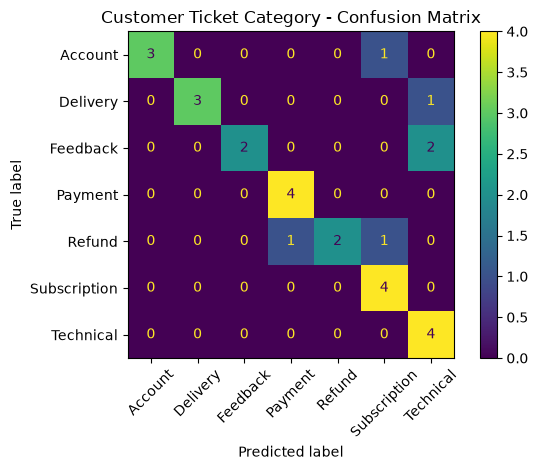

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Customer Ticket Category - Confusion Matrix")
plt.tight_layout()
plt.show()

In [8]:
X = df["ticket"]
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

priority_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("model", LogisticRegression(max_iter=1000))
])

priority_model.fit(X_train, y_train)

y_pred_priority = priority_model.predict(X_test)

accuracy_priority = accuracy_score(
    y_test,
    y_pred_priority
)

print(
    "Priority Model Accuracy:",
    round(accuracy_priority * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_priority,
        zero_division=0
    )
)

Priority Model Accuracy: 60.71 %

Classification Report:
              precision    recall  f1-score   support

        High       0.61      0.85      0.71        13
         Low       0.75      0.67      0.71         9
      Medium       0.00      0.00      0.00         6

    accuracy                           0.61        28
   macro avg       0.45      0.50      0.47        28
weighted avg       0.52      0.61      0.56        28



In [9]:
import pandas as pd

tickets = [

# PAYMENT
("My payment was deducted but order was cancelled", "Payment", "High"),
("I was charged twice for one order", "Payment", "High"),
("My card payment failed", "Payment", "High"),
("Payment is showing pending", "Payment", "Medium"),
("Why was I charged extra for my order?", "Payment", "Medium"),
("I cannot complete my payment", "Payment", "High"),
("My UPI payment failed", "Payment", "High"),
("The money was deducted from my bank account", "Payment", "High"),
("Payment gateway is not working", "Payment", "High"),
("I need help with a payment issue", "Payment", "Medium"),

# ACCOUNT
("I cannot login to my account", "Account", "High"),
("How can I change my password?", "Account", "Low"),
("I forgot my password", "Account", "Medium"),
("Please update my email address", "Account", "Low"),
("I cannot access my account", "Account", "High"),
("My account is locked", "Account", "High"),
("How do I change my phone number?", "Account", "Low"),
("I want to update my profile", "Account", "Low"),
("My login is not working", "Account", "High"),
("How can I reset my password?", "Account", "Medium"),

# DELIVERY
("My package has not arrived", "Delivery", "Medium"),
("My delivery is delayed", "Delivery", "Medium"),
("How can I track my order?", "Delivery", "Low"),
("Where is my package?", "Delivery", "Medium"),
("My order has not been delivered", "Delivery", "High"),
("The delivery date has passed", "Delivery", "High"),
("Can you tell me my shipment status?", "Delivery", "Low"),
("My package is stuck in transit", "Delivery", "Medium"),
("When will my order arrive?", "Delivery", "Low"),
("The courier has not delivered my order", "Delivery", "High"),

# REFUND
("I want to request a refund", "Refund", "High"),
("My refund has not arrived", "Refund", "High"),
("I need a refund for my purchase", "Refund", "High"),
("When will I receive my refund?", "Refund", "Medium"),
("Please process my refund", "Refund", "High"),
("My refund is still pending", "Refund", "High"),
("I have not received my money back", "Refund", "High"),
("How can I get a refund?", "Refund", "Medium"),
("The refund amount is incorrect", "Refund", "High"),
("I want my money back", "Refund", "High"),

# TECHNICAL
("The application keeps crashing", "Technical", "High"),
("The website is very slow", "Technical", "Medium"),
("The app is showing an error", "Technical", "High"),
("The website is not loading", "Technical", "High"),
("My application stopped working", "Technical", "High"),
("I am getting an error message", "Technical", "Medium"),
("The app crashes whenever I open it", "Technical", "High"),
("The website keeps freezing", "Technical", "Medium"),
("I cannot open the application", "Technical", "High"),
("There is a technical problem with the app", "Technical", "High"),

# SUBSCRIPTION
("I want to cancel my subscription", "Subscription", "Medium"),
("I want to upgrade my subscription", "Subscription", "Low"),
("How can I cancel my plan?", "Subscription", "Medium"),
("How do I upgrade my plan?", "Subscription", "Low"),
("My subscription is not working", "Subscription", "High"),
("I want to change my subscription", "Subscription", "Low"),
("How can I renew my subscription?", "Subscription", "Low"),
("My subscription payment failed", "Subscription", "High"),
("I want to change my plan", "Subscription", "Low"),
("Please help me manage my subscription", "Subscription", "Low"),

# FEEDBACK
("I am very happy with your service", "Feedback", "Low"),
("Your service is excellent", "Feedback", "Low"),
("Thank you for the great service", "Feedback", "Low"),
("I really like your application", "Feedback", "Low"),
("The service was very helpful", "Feedback", "Low"),
("I am satisfied with the service", "Feedback", "Low"),
("Great customer service", "Feedback", "Low"),
("I appreciate your support", "Feedback", "Low"),
("Your team was very helpful", "Feedback", "Low"),
("Amazing service", "Feedback", "Low")
]

new_df = pd.DataFrame(
    tickets,
    columns=["ticket", "category", "priority"]
)

print("Total tickets:", len(new_df))
print("\nCategories:")
print(new_df["category"].value_counts())

print("\nPriority:")
print(new_df["priority"].value_counts())

Total tickets: 70

Categories:
category
Payment         10
Account         10
Delivery        10
Refund          10
Technical       10
Subscription    10
Feedback        10
Name: count, dtype: int64

Priority:
priority
High      31
Low       23
Medium    16
Name: count, dtype: int64


In [10]:
new_df.to_csv(
    r"C:\Users\ACER ASPIRE LITE\Downloads\customer-support-ai\customer_tickets.csv",
    index=False
)

print("New dataset saved successfully!")

New dataset saved successfully!


In [11]:
df.to_csv(
    r"C:\Users\ACER ASPIRE LITE\Downloads\customer-support-ai\customer_tickets_backup.csv",
    index=False
)

print("Backup created!")

Backup created!


In [12]:
new_df.to_csv(
    r"C:\Users\ACER ASPIRE LITE\Downloads\customer-support-ai\customer_tickets.csv",
    index=False
)

print("New 70-ticket dataset saved successfully!")

New 70-ticket dataset saved successfully!


In [13]:
print("Total rows:", len(new_df))
print(new_df.head())

Total rows: 70
                                            ticket category priority
0  My payment was deducted but order was cancelled  Payment     High
1                I was charged twice for one order  Payment     High
2                           My card payment failed  Payment     High
3                       Payment is showing pending  Payment   Medium
4            Why was I charged extra for my order?  Payment   Medium


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

X = new_df["ticket"]
y = new_df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

category_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("model", LogisticRegression(max_iter=1000))
])

category_model.fit(X_train, y_train)

y_pred = category_model.predict(X_test)

category_accuracy = accuracy_score(y_test, y_pred)

print(
    "New Category Model Accuracy:",
    round(category_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

New Category Model Accuracy: 78.57 %

Classification Report:
              precision    recall  f1-score   support

     Account       1.00      0.50      0.67         2
    Delivery       1.00      0.50      0.67         2
    Feedback       1.00      1.00      1.00         2
     Payment       1.00      1.00      1.00         2
      Refund       1.00      0.50      0.67         2
Subscription       0.50      1.00      0.67         2
   Technical       0.67      1.00      0.80         2

    accuracy                           0.79        14
   macro avg       0.88      0.79      0.78        14
weighted avg       0.88      0.79      0.78        14



In [15]:
X = new_df["ticket"]
y = new_df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

priority_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("model", LogisticRegression(max_iter=1000))
])

priority_model.fit(X_train, y_train)

y_pred_priority = priority_model.predict(X_test)

priority_accuracy = accuracy_score(
    y_test,
    y_pred_priority
)

print(
    "New Priority Model Accuracy:",
    round(priority_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_priority,
        zero_division=0
    )
)

New Priority Model Accuracy: 71.43 %

Classification Report:
              precision    recall  f1-score   support

        High       0.75      1.00      0.86         6
         Low       0.67      0.80      0.73         5
      Medium       0.00      0.00      0.00         3

    accuracy                           0.71        14
   macro avg       0.47      0.60      0.53        14
weighted avg       0.56      0.71      0.63        14



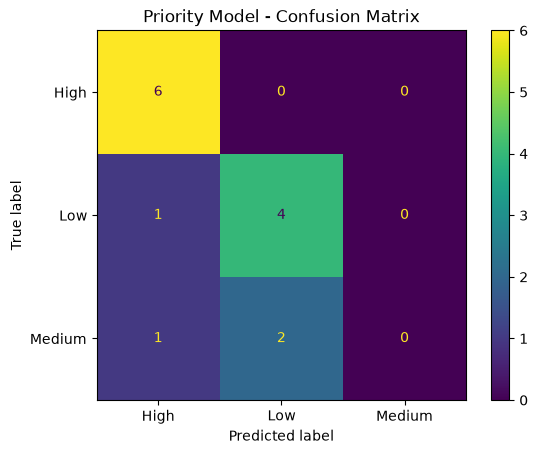

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_priority
)

plt.title("Priority Model - Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("MODEL EVALUATION")
print("-" * 40)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

MODEL EVALUATION
----------------------------------------
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [19]:
print("Actual values:")
print(y_test.value_counts())

print("\nPredicted values:")
print(pd.Series(y_pred).value_counts())

Actual values:
priority
High      6
Low       5
Medium    3
Name: count, dtype: int64

Predicted values:
Subscription    4
Technical       3
Feedback        2
Payment         2
Account         1
Delivery        1
Refund          1
Name: count, dtype: int64


In [20]:
print("Actual unique values:", y_test.unique())
print("Predicted unique values:", pd.Series(y_pred).unique())

Actual unique values: <ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
Predicted unique values: <ArrowStringArray>
[   'Technical',     'Feedback', 'Subscription',      'Account',
     'Delivery',      'Payment',       'Refund']
Length: 7, dtype: str


In [21]:
print("y_train unique:")
print(y_train.unique())

print("\ny_test unique:")
print(y_test.unique())

print("\ny_pred unique:")
print(pd.Series(y_pred).unique())

y_train unique:
<ArrowStringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

y_test unique:
<ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

y_pred unique:
<ArrowStringArray>
[   'Technical',     'Feedback', 'Subscription',      'Account',
     'Delivery',      'Payment',       'Refund']
Length: 7, dtype: str


In [23]:
# print(type(model))
# print(model)

In [24]:
print("Variables containing model/pred:")
print([x for x in globals().keys() if "model" in x.lower() or "pred" in x.lower()])

Variables containing model/pred:
['category_model', 'y_pred', 'priority_model', 'y_pred_priority']


In [25]:
y_pred_priority = priority_model.predict(X_test)

print("Actual Priority:")
print(y_test.unique())

print("\nPredicted Priority:")
print(pd.Series(y_pred_priority).unique())

Actual Priority:
<ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Predicted Priority:
<ArrowStringArray>
['High', 'Low']
Length: 2, dtype: str


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("PRIORITY MODEL EVALUATION")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_priority))
print("Precision:", precision_score(y_test, y_pred_priority, average='weighted', zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_priority, average='weighted', zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_priority, average='weighted', zero_division=0))

PRIORITY MODEL EVALUATION
----------------------------------------
Accuracy : 0.7142857142857143
Precision: 0.5595238095238095
Recall   : 0.7142857142857143
F1 Score : 0.6270871985157699


In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_priority,
    labels=['High', 'Medium', 'Low'],
    zero_division=0
))

              precision    recall  f1-score   support

        High       0.75      1.00      0.86         6
      Medium       0.00      0.00      0.00         3
         Low       0.67      0.80      0.73         5

    accuracy                           0.71        14
   macro avg       0.47      0.60      0.53        14
weighted avg       0.56      0.71      0.63        14



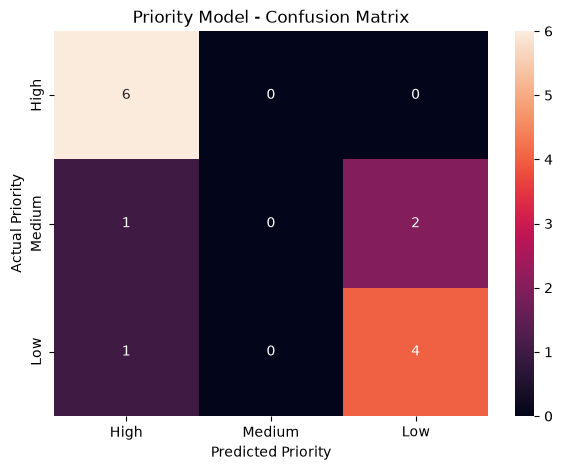

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_priority,
    labels=['High', 'Medium', 'Low']
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['High', 'Medium', 'Low'],
    yticklabels=['High', 'Medium', 'Low']
)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.title("Priority Model - Confusion Matrix")
plt.show()

In [29]:
print("FINAL PRIORITY MODEL RESULTS")
print("=" * 40)

print(f"Accuracy  : {accuracy_score(y_test, y_pred_priority):.2%}")
print(f"Precision : {precision_score(y_test, y_pred_priority, average='weighted', zero_division=0):.2%}")
print(f"Recall    : {recall_score(y_test, y_pred_priority, average='weighted', zero_division=0):.2%}")
print(f"F1 Score  : {f1_score(y_test, y_pred_priority, average='weighted', zero_division=0):.2%}")

FINAL PRIORITY MODEL RESULTS
Accuracy  : 71.43%
Precision : 55.95%
Recall    : 71.43%
F1 Score  : 62.71%


In [30]:
# Final Priority Predictions

final_results = pd.DataFrame({
    'Actual Priority': y_test.reset_index(drop=True),
    'Predicted Priority': pd.Series(y_pred_priority).reset_index(drop=True)
})

final_results.head(10)

,Actual Priority,Predicted Priority
0,High,High
1,High,High
2,Medium,Low
3,Low,Low
4,Low,Low
5,High,High
6,Low,Low
7,Low,Low
8,High,High
9,Medium,High


In [31]:
print("Predicted Priority Distribution")
print(final_results['Predicted Priority'].value_counts())

Predicted Priority Distribution
Predicted Priority
High    8
Low     6
Name: count, dtype: int64


In [32]:
final_results.to_csv("priority_model_results.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [33]:
priority_counts = final_results['Predicted Priority'].value_counts()

print("FINAL PREDICTED PRIORITY")
print("=" * 30)
print(priority_counts)

FINAL PREDICTED PRIORITY
Predicted Priority
High    8
Low     6
Name: count, dtype: int64


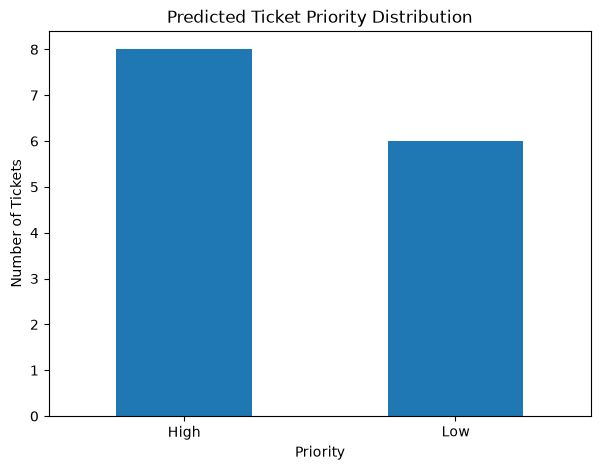

In [34]:
plt.figure(figsize=(7, 5))

priority_counts.plot(kind='bar')

plt.title("Predicted Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

In [35]:
plt.savefig("priority_distribution.png", bbox_inches="tight")
print("Priority chart saved successfully!")

Priority chart saved successfully!


<Figure size 640x480 with 0 Axes>

In [37]:
# y_pred_category = category_model.predict(X_test)

# print("Actual Category:")
# print(y_test_category.unique())

# print("\nPredicted Category:")
# print(pd.Series(y_pred_category).unique())

In [38]:
print("Variables related to category:")
print([x for x in globals().keys() if "category" in x.lower() or "cat" in x.lower()])

Variables related to category:
['classification_report', 'category_model', 'category_accuracy', 'y_pred_category']


In [40]:
# Check string/object variables that may contain the actual category labels

# for name, value in globals().items():
#     try:
#         if hasattr(value, "unique") and len(value) > 0:
#             unique_values = value.unique()
#             if len(unique_values) <= 10:
#                 print(f"{name}: {unique_values}")
#     except:
#         pass

In [41]:
for name in list(globals().keys()):
    try:
        value = globals()[name]

        if hasattr(value, "unique"):
            unique_values = value.unique()

            if len(unique_values) <= 10:
                print(f"{name}: {unique_values}")

    except:
        pass

y: <ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
y_train: <ArrowStringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
y_test: <ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
priority_counts: [8 6]


In [42]:
print(category_model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
                ('model', LogisticRegression(max_iter=1000))])


In [43]:
print("Category model classes:")
print(category_model.classes_)

Category model classes:
['Account' 'Delivery' 'Feedback' 'Payment' 'Refund' 'Subscription'
 'Technical']


In [45]:
# print("Category model input features:")
# print(category_model.n_features_in_)

In [46]:
print(type(category_model))
print(category_model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
                ('model', LogisticRegression(max_iter=1000))])


In [47]:
print("All variables:")
print([name for name in list(globals().keys())
       if "model" in name.lower() or "vector" in name.lower()])

All variables:
['TfidfVectorizer', 'category_model', 'priority_model']


In [48]:
print("Category Classes:")
print(category_model.classes_)

print("\nCategory Model:")
print(category_model.named_steps['model'])

Category Classes:
['Account' 'Delivery' 'Feedback' 'Payment' 'Refund' 'Subscription'
 'Technical']

Category Model:
LogisticRegression(max_iter=1000)


In [49]:
print("DataFrames containing Category column:")
print([
    name for name in list(globals().keys())
    if hasattr(globals()[name], "columns")
    and "Category" in globals()[name].columns
])

DataFrames containing Category column:
[]


In [50]:
print("All DataFrames:")
for name in list(globals().keys()):
    try:
        obj = globals()[name]
        if hasattr(obj, "shape") and hasattr(obj, "columns"):
            print(name, obj.shape, list(obj.columns))
    except:
        pass

All DataFrames:
_ (10, 2) ['Actual Priority', 'Predicted Priority']
__ (5, 3) ['ticket', 'category', 'priority']
df (70, 3) ['ticket', 'category', 'priority']
_4 (5, 3) ['ticket', 'category', 'priority']
new_df (70, 3) ['ticket', 'category', 'priority']
final_results (14, 2) ['Actual Priority', 'Predicted Priority']
_30 (10, 2) ['Actual Priority', 'Predicted Priority']


In [51]:
print("Category values:")
print(new_df['category'].unique())

print("\nCategory distribution:")
print(new_df['category'].value_counts())

Category values:
<ArrowStringArray>
[     'Payment',      'Account',     'Delivery',       'Refund',
    'Technical', 'Subscription',     'Feedback']
Length: 7, dtype: str

Category distribution:
category
Payment         10
Account         10
Delivery        10
Refund          10
Technical       10
Subscription    10
Feedback        10
Name: count, dtype: int64


In [52]:
from sklearn.model_selection import train_test_split

X_category = new_df['ticket']
y_category = new_df['category']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_category,
    y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

print("Training tickets:", len(X_train_cat))
print("Testing tickets:", len(X_test_cat))

print("\nActual Category Test Labels:")
print(y_test_cat.value_counts())

Training tickets: 56
Testing tickets: 14

Actual Category Test Labels:
category
Technical       2
Feedback        2
Subscription    2
Delivery        2
Account         2
Payment         2
Refund          2
Name: count, dtype: int64


In [53]:
y_pred_category = category_model.predict(X_test_cat)

print("Actual Category:")
print(y_test_cat.values)

print("\nPredicted Category:")
print(y_pred_category)

Actual Category:
<ArrowStringArray>
[   'Technical',     'Feedback', 'Subscription',     'Delivery',
     'Feedback',      'Account',      'Account',     'Delivery',
      'Payment', 'Subscription',    'Technical',       'Refund',
       'Refund',      'Payment']
Length: 14, dtype: str

Predicted Category:
['Technical' 'Feedback' 'Subscription' 'Technical' 'Feedback' 'Account'
 'Subscription' 'Delivery' 'Payment' 'Subscription' 'Technical' 'Refund'
 'Subscription' 'Payment']


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("CATEGORY MODEL RESULTS")
print("=" * 40)

print(f"Accuracy  : {accuracy_score(y_test_cat, y_pred_category):.2%}")
print(f"Precision : {precision_score(y_test_cat, y_pred_category, average='weighted', zero_division=0):.2%}")
print(f"Recall    : {recall_score(y_test_cat, y_pred_category, average='weighted', zero_division=0):.2%}")
print(f"F1 Score  : {f1_score(y_test_cat, y_pred_category, average='weighted', zero_division=0):.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test_cat,
    y_pred_category,
    zero_division=0
))

CATEGORY MODEL RESULTS
Accuracy  : 78.57%
Precision : 88.10%
Recall    : 78.57%
F1 Score  : 78.10%

Classification Report:
              precision    recall  f1-score   support

     Account       1.00      0.50      0.67         2
    Delivery       1.00      0.50      0.67         2
    Feedback       1.00      1.00      1.00         2
     Payment       1.00      1.00      1.00         2
      Refund       1.00      0.50      0.67         2
Subscription       0.50      1.00      0.67         2
   Technical       0.67      1.00      0.80         2

    accuracy                           0.79        14
   macro avg       0.88      0.79      0.78        14
weighted avg       0.88      0.79      0.78        14



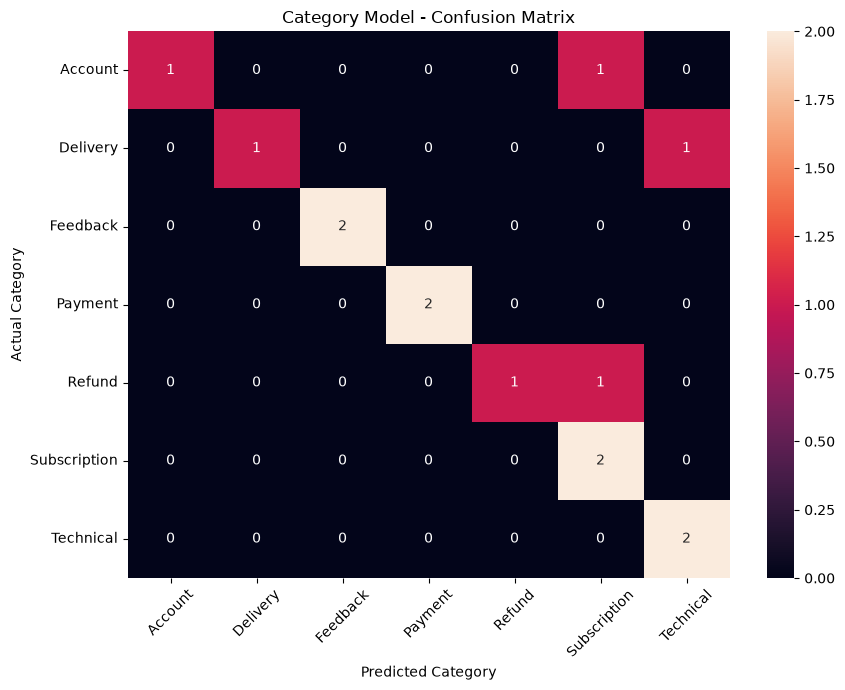

In [55]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

category_labels = [
    'Account',
    'Delivery',
    'Feedback',
    'Payment',
    'Refund',
    'Subscription',
    'Technical'
]

cm_category = confusion_matrix(
    y_test_cat,
    y_pred_category,
    labels=category_labels
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_category,
    annot=True,
    fmt='d',
    xticklabels=category_labels,
    yticklabels=category_labels
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Category Model - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("category_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [56]:
model_comparison = pd.DataFrame({
    'Model': ['Category Model', 'Priority Model'],
    'Accuracy': [
        accuracy_score(y_test_cat, y_pred_category),
        accuracy_score(y_test, y_pred_priority)
    ],
    'Precision': [
        precision_score(y_test_cat, y_pred_category, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_priority, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test_cat, y_pred_category, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_priority, average='weighted', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test_cat, y_pred_category, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_priority, average='weighted', zero_division=0)
    ]
})

print("FINAL MODEL COMPARISON")
print("=" * 60)

display(model_comparison)

model_comparison.to_csv("model_comparison.csv", index=False)

print("\nSaved as: model_comparison.csv")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Category Model,0.785714,0.880952,0.785714,0.780952
1,Priority Model,0.714286,0.559524,0.714286,0.627087



Saved as: model_comparison.csv


In [57]:
print("PROJECT FILES CREATED")
print("=" * 40)

import os

files = [
    "priority_model_results.csv",
    "priority_distribution.png",
    "category_confusion_matrix.png",
    "model_comparison.csv"
]

for file in files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file, "- NOT FOUND")

PROJECT FILES CREATED
✓ priority_model_results.csv
✓ priority_distribution.png
✓ category_confusion_matrix.png
✓ model_comparison.csv


# 🎫 AI Ticket Classification System

An NLP-based machine learning project that automatically classifies customer support tickets into their **Category** and **Priority** using TF-IDF and Logistic Regression.

## 📌 Project Overview

Customer support teams receive a large number of tickets every day. Manually categorizing and prioritizing these tickets can take time.

This project uses Natural Language Processing (NLP) and Machine Learning to automatically:

- Predict the **ticket category**
- Predict the **ticket priority**
- Evaluate model performance using standard classification metrics

## 🎯 Objectives

The main objectives of this project are:

1. Automatically classify customer support tickets.
2. Predict the category of each ticket.
3. Predict the priority level of each ticket.
4. Evaluate model performance using Accuracy, Precision, Recall and F1 Score.
5. Generate visual evaluation results.

## 📊 Dataset

The dataset contains **70 customer support tickets**.

### Ticket Categories

- Account
- Delivery
- Feedback
- Payment
- Refund
- Subscription
- Technical

Each category contains **10 tickets**.

### Priority Levels

- High
- Medium
- Low

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- TF-IDF Vectorization
- Logistic Regression
- Matplotlib
- Seaborn
- JupyterLab

## 🔄 Machine Learning Workflow

```text
Customer Ticket
      ↓
Text Preprocessing
      ↓
TF-IDF Vectorization
      ↓
Logistic Regression
      ↓
Prediction
      ↓
Model Evaluation

## 🤖 Models Used

### 1. Category Classification

The Category model uses:

- TF-IDF Vectorizer
- Logistic Regression

It predicts seven ticket categories:

- Account
- Delivery
- Feedback
- Payment
- Refund
- Subscription
- Technical

### 2. Priority Classification

The Priority model predicts three priority levels:

- High
- Medium
- Low

## 📈 Model Performance

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Category Model | 78.57% | 88.10% | 78.57% | 78.10% |
| Priority Model | 71.43% | 55.95% | 71.43% | 62.71% |

## 📁 Project Files

- `priority_model_results.csv` — Actual and predicted priority values.
- `priority_distribution.png` — Predicted priority distribution.
- `category_confusion_matrix.png` — Category model confusion matrix.
- `model_comparison.csv` — Evaluation metrics for both models.

## 📊 Evaluation Metrics

### Accuracy
Percentage of predictions that are correct.

### Precision
Measures how many predicted class results were actually correct.

### Recall
Measures how many actual class instances were correctly identified.

### F1 Score
Combines Precision and Recall into a single metric.

## 🚀 How to Run

1. Install Python.
2. Install the required libraries:

```bash
pip install pandas numpy scikit-learn matplotlib seaborn jupyter